# Fintech Income Analysis (Monthly Rollup)

Run this notebook step-by-step to inspect the refactored monthly-rollup income model. If the notebook still shows old interval columns in rendered output, rerun cells from the top so the saved outputs refresh.

Phases:
1. Raw monthly evidence for one account: what each sender paid each month before labels.
2. Model interpretation: cluster profiles plus sender labels for the selected account.
3. Income estimate: account-level totals and monthly income timeline by label.
4. Scale to all accounts: portfolio-wide account summaries and exportable sender dataset.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

%matplotlib inline

# Resolve project_root (same logic as original — kept separate so ACCOUNT_ID cell can run standalone)
candidates = [Path.cwd(), Path.cwd().parent]
project_root = None
for p in candidates:
    if (p / "colab" / "step1_colab_demo.py").exists():
        project_root = p
        break
if project_root is None:
    raise RuntimeError("Could not locate project root containing colab/step1_colab_demo.py")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from colab.step1_colab_demo import load_raw_data
from step1_inline_income_model import (
    FEATURE_COLS,
    apply_income_evidence_rules,
    build_features,
    kmeans_confidence,
    map_clusters_to_income,
)

try:
    from IPython.display import display
except Exception:
    display = None


def show_table(frame: pd.DataFrame, title: str, page_length: int = 25) -> None:
    # Keep a stable table renderer even when cells run out of order.
    print(f"\n{title}")
    if display is not None:
        display(frame)
    else:
        print(frame.to_string(index=False))


# Color scheme for income types
COLORS = {
    "salary_income": "#2E86AB",
    "sme_business_income": "#A23B72",
    "other_irregular_income": "#F18F01",
}

# Consistent readable plotting defaults
plt.style.use("seaborn-v0_8-whitegrid")
LABELS = {
    "salary_income": "Salary",
    "sme_business_income": "SME Business",
    "other_irregular_income": "Other/Irregular",
}

In [2]:
# Update account id only; CSV path is auto-resolved.
ACCOUNT_ID = "99"

candidate_csv_paths = [
    project_root / "outputs" / "colab" / "credit_transactions.csv",
    project_root / "credit_transactions.csv",
    Path.cwd() / "credit_transactions.csv",
]

CSV_PATH = None
for p in candidate_csv_paths:
    if p.exists():
        CSV_PATH = str(p)
        break

if CSV_PATH is None:
    raise FileNotFoundError(
        "Could not find credit_transactions.csv. Expected one of: "
        + ", ".join(str(p) for p in candidate_csv_paths)
    )

print("Using CSV_PATH:", CSV_PATH)


Using CSV_PATH: /Users/enkhtuvsin/Work/statement_model/outputs/colab/credit_transactions.csv


## Phase 1 - Raw Monthly Evidence (One Account)

This phase answers: what actually happened for the selected account before model labels?

The table is grouped by `sender` and `month`, so split salary payments in the same month are visible as one monthly total with a transaction count. This is the evidence layer that the refactored model uses before KMeans labels are applied.

In [3]:
# Guard against running this cell out of order.
if "ACCOUNT_ID" not in globals():
    ACCOUNT_ID = "99"

if "CSV_PATH" not in globals():
    candidate_csv_paths = [
        project_root / "outputs" / "colab" / "credit_transactions.csv",
        project_root / "credit_transactions.csv",
        Path.cwd() / "credit_transactions.csv",
    ]
    CSV_PATH = None
    for p in candidate_csv_paths:
        if p.exists():
            CSV_PATH = str(p)
            break
    if CSV_PATH is None:
        raise FileNotFoundError(
            "Could not find credit_transactions.csv. Expected one of: "
            + ", ".join(str(p) for p in candidate_csv_paths)
        )

raw_df = load_raw_data(CSV_PATH)
transactions = pd.read_csv(CSV_PATH)
features = build_features(transactions)

scaler = StandardScaler()
X = scaler.fit_transform(features[FEATURE_COLS])
model = KMeans(n_clusters=3, random_state=42, n_init="auto")
labels = model.fit_predict(X)
distances = model.transform(X)

monthly_model_output = features.copy()
monthly_model_output["cluster_id"] = labels
monthly_model_output["confidence_score"] = kmeans_confidence(distances, labels).clip(0, 0.99)
monthly_model_output["predicted_income_type"] = monthly_model_output["cluster_id"].map(
    map_clusters_to_income(monthly_model_output)
)
monthly_model_output = apply_income_evidence_rules(monthly_model_output)

account_model = monthly_model_output[
    monthly_model_output["account_id"].astype(str) == str(ACCOUNT_ID)
].copy()

phase1_cols = [
    "account_id",
    "sender",
    "cluster_income_type",
    "predicted_income_type",
    "income_label_rule",
    "salary_evidence_score",
    "salary_evidence_flags",
    "confidence_score",
    "total_txns",
    "average_monthly_amount",
    "active_months",
    "average_txns_per_month",
    "sender_txn_share_in_account",
    "monthly_amount_cv",
]

account_transactions = transactions.copy()
account_transactions["transaction_date"] = pd.to_datetime(
    account_transactions["transaction_date"], errors="coerce"
)
month_source = account_transactions["transaction_date"]
if getattr(month_source.dt, "tz", None) is not None:
    month_source = month_source.dt.tz_localize(None)
account_transactions["month"] = month_source.dt.to_period("M").astype(str)
account_transactions = account_transactions[
    account_transactions["account_id"].astype(str) == str(ACCOUNT_ID)
].copy()

account_monthly_evidence = (
    account_transactions.groupby(["sender", "month"], as_index=False)
    .agg(
        monthly_total_amount=("amount", "sum"),
        txns_in_month=("amount", "size"),
    )
    .sort_values(["monthly_total_amount", "sender", "month"], ascending=[False, True, True])
)

print("Monthly Rollup KMeans Metrics")
print(f"Rows: {len(monthly_model_output)}")
print(f"Accounts: {monthly_model_output['account_id'].nunique()}")
print(f"Silhouette: {silhouette_score(X, labels):.4f}")
print(f"Davies-Bouldin: {davies_bouldin_score(X, labels):.4f}")
print(f"Avg confidence: {monthly_model_output['confidence_score'].mean():.4f}")

print(f"\nRaw monthly sender evidence for account_id={ACCOUNT_ID}")
account_monthly_evidence.head(30)


Monthly Rollup KMeans Metrics
Rows: 1452
Accounts: 23
Silhouette: 0.7222
Davies-Bouldin: 0.9304
Avg confidence: 0.8134

Raw monthly sender evidence for account_id=99


,sender,month,monthly_total_amount,txns_in_month
54,5122047445.0,2026-01,4619700.0,3
42,5042210956.0,2025-09,2000000.0,1
50,5122047445.0,2025-09,2000000.0,2
51,5122047445.0,2025-10,2000000.0,2
52,5122047445.0,2025-11,2000000.0,2
53,5122047445.0,2025-12,2000000.0,2
55,5122047445.0,2026-02,1900000.0,1
12,1205112386.0,2025-12,1650000.0,2
47,5111836329.0,2025-11,1600000.0,2
3,1105351490.0,2026-01,1277400.0,5


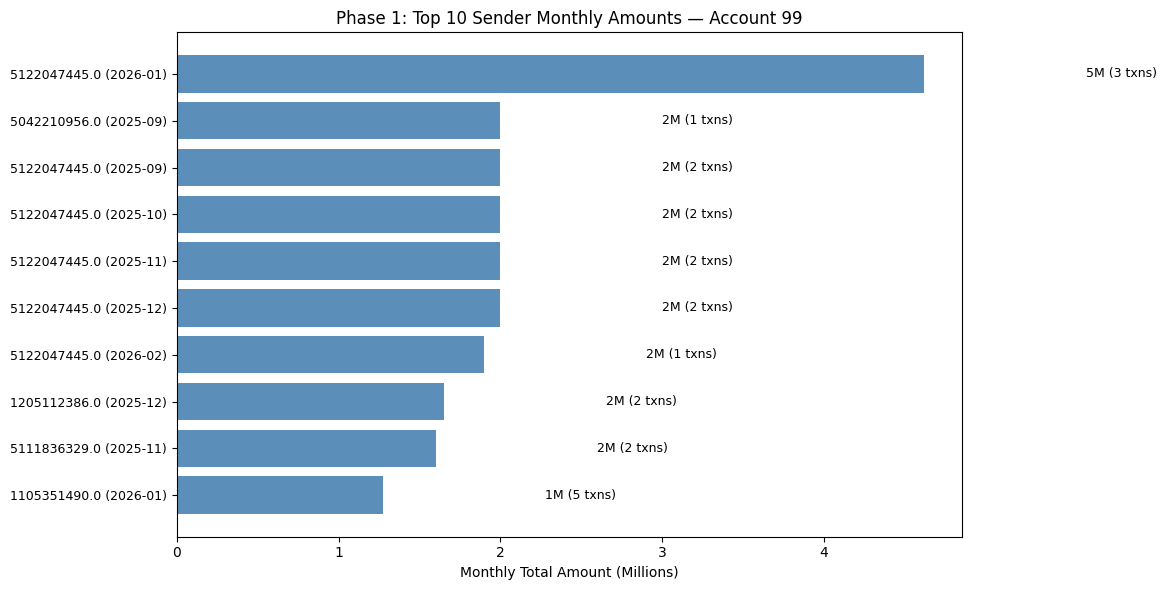

In [4]:
# Phase 1 Visualization: Top 10 Sender-Month Amounts
top_senders = account_monthly_evidence.sort_values(
    ["monthly_total_amount", "txns_in_month"], ascending=[False, False]
).head(10).copy()
top_senders["monthly_total_millions"] = top_senders["monthly_total_amount"] / 1_000_000
labels = [f"{s} ({m})" for s, m in zip(top_senders["sender"], top_senders["month"])]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(labels, top_senders["monthly_total_millions"], color="#5B8FB9", edgecolor="black", alpha=0.85)
ax.set_xlabel("Monthly Total Amount (Millions)")
ax.set_title(f"Phase 1: Top 10 Sender-Month Amounts — Account {ACCOUNT_ID}")
ax.invert_yaxis()
ax.bar_label(
    bars,
    labels=[f"{v:,.2f}M | {t} txns" for v, t in zip(top_senders["monthly_total_millions"], top_senders["txns_in_month"])],
    padding=4,
    fontsize=9,
)
plt.tight_layout()
plt.show()

## Phase 2 - Model Interpretation

This phase answers: how did KMeans separate the senders, and which labels did the selected account receive?

The first table is cluster-level. The second table is sender-level labels for `ACCOUNT_ID`.

In [5]:
if "LABEL_ORDER" not in globals():
    LABEL_ORDER = {
        "salary_income": 0,
        "sme_business_income": 1,
        "other_irregular_income": 2,
    }

cluster_profile = (
    monthly_model_output.groupby(["cluster_id", "predicted_income_type"], as_index=False)
    .agg(
        rows=("sender", "size"),
        total_txns=("total_txns", "mean"),
        average_monthly_amount=("average_monthly_amount", "mean"),
        active_months=("active_months", "mean"),
        average_txns_per_month=("average_txns_per_month", "mean"),
        sender_txn_share_in_account=("sender_txn_share_in_account", "mean"),
        monthly_amount_cv=("monthly_amount_cv", "mean"),
        confidence_score=("confidence_score", "mean"),
    )
)
cluster_profile["label_order"] = cluster_profile["predicted_income_type"].map(LABEL_ORDER)
cluster_profile = cluster_profile.sort_values(["label_order", "cluster_id"]).drop(columns="label_order")

account_distribution = (
    account_model["predicted_income_type"]
    .value_counts()
    .rename_axis("predicted_income_type")
    .reset_index(name="sender_count")
)
account_distribution["label_order"] = account_distribution["predicted_income_type"].map(LABEL_ORDER)
account_distribution = account_distribution.sort_values("label_order").drop(columns="label_order")

account_label_view = account_model[phase1_cols].copy()
account_label_view["label_order"] = account_label_view["predicted_income_type"].map(LABEL_ORDER)
account_label_view = account_label_view.sort_values(
    ["label_order", "confidence_score", "total_txns"],
    ascending=[True, False, False],
).drop(columns="label_order")

salary_senders = account_label_view[account_label_view["predicted_income_type"].eq("salary_income")]
sme_senders = account_label_view[account_label_view["predicted_income_type"].eq("sme_business_income")]
irregular_senders = account_label_view[account_label_view["predicted_income_type"].eq("other_irregular_income")]

override_cols = [
    "account_id",
    "sender",
    "cluster_income_type",
    "predicted_income_type",
    "income_label_rule",
    "salary_evidence_score",
    "salary_evidence_flags",
    "confidence_score",
    "active_months",
    "average_txns_per_month",
    "monthly_amount_cv",
]
promoted_salary = account_label_view[
    account_label_view["income_label_rule"].eq("high_recurrence_salary_override")
][override_cols]
demoted_salary = account_label_view[
    account_label_view["income_label_rule"].eq("low_recurrence_override")
][override_cols]
unchanged_cluster = account_label_view[
    account_label_view["income_label_rule"].eq("cluster_model")
][override_cols]

show_table(cluster_profile, title="Monthly Rollup Cluster Profiles", page_length=10)
show_table(account_distribution, title=f"Account {ACCOUNT_ID} Label Distribution", page_length=10)
show_table(promoted_salary, title=f"Account {ACCOUNT_ID} Promoted Salary Overrides", page_length=25)
show_table(demoted_salary, title=f"Account {ACCOUNT_ID} Demoted Salary Overrides", page_length=25)
show_table(unchanged_cluster, title=f"Account {ACCOUNT_ID} Unchanged Cluster Labels", page_length=25)
show_table(salary_senders, title=f"Account {ACCOUNT_ID} Salary Senders", page_length=25)
show_table(sme_senders, title=f"Account {ACCOUNT_ID} SME Senders", page_length=25)
show_table(irregular_senders, title=f"Account {ACCOUNT_ID} Other / Irregular Senders", page_length=25)



Monthly Rollup Cluster Profiles


,cluster_id,predicted_income_type,rows,total_txns,average_monthly_amount,active_months,average_txns_per_month,sender_txn_share_in_account,monthly_amount_cv,confidence_score
1,0,salary_income,1,5.000000,1.278000e+06,4.000000,1.250000,0.020000,0.033058,0.600000
2,1,salary_income,21,9.047619,3.546848e+06,6.047619,1.528389,0.050806,0.130041,0.600000
5,2,salary_income,21,42.095238,1.443085e+07,7.190476,6.312924,0.235845,0.331433,0.538420
3,1,sme_business_income,189,5.835979,5.483698e+06,3.079365,1.948450,0.038669,0.637587,0.542450
0,0,other_irregular_income,1219,1.232158,2.548393e+06,1.068089,1.145338,0.007097,0.006796,0.864350
4,2,other_irregular_income,1,1.000000,9.000000e+05,1.000000,1.000000,1.000000,0.000000,0.366476



Account 99 Label Distribution


,predicted_income_type,sender_count
2,salary_income,1
1,sme_business_income,10
0,other_irregular_income,24



Account 99 Promoted Salary Overrides


...

,account_id,sender,cluster_income_type,predicted_income_type,income_label_rule,salary_evidence_score,salary_evidence_flags,confidence_score,total_txns,average_monthly_amount,active_months,average_txns_per_month,sender_txn_share_in_account,monthly_amount_cv
1449,99,5122047445.0,sme_business_income,salary_income,high_recurrence_salary_override,0.9916,months=1|cv=1|schedule=1|share=1,0.6,12,2419950.0,6,2.0,0.129032,0.01687



Account 99 SME Senders


,account_id,sender,cluster_income_type,predicted_income_type,income_label_rule,salary_evidence_score,salary_evidence_flags,confidence_score,total_txns,average_monthly_amount,active_months,average_txns_per_month,sender_txn_share_in_account,monthly_amount_cv
1442,99,3305123366.0,sme_business_income,sme_business_income,cluster_model,0.3208,months=0|cv=0|schedule=1|share=1,0.645651,5,410000.000000,2,2.500000,0.053763,0.724353
1420,99,1175137757.0,sme_business_income,sme_business_income,cluster_model,0.4690,months=0|cv=0|schedule=1|share=1,0.606437,4,64516.666667,3,1.333333,0.043011,0.370035
1448,99,5111836329.0,sme_business_income,sme_business_income,cluster_model,0.6693,months=1|cv=0|schedule=1|share=1,0.599066,7,616000.000000,5,1.400000,0.075269,0.383646
1427,99,1605145454.0,sme_business_income,sme_business_income,cluster_model,0.3208,months=0|cv=0|schedule=1|share=1,0.552957,5,99125.000000,2,2.500000,0.053763,1.193789
1441,99,3055227111.0,sme_business_income,sme_business_income,cluster_model,0.2103,months=0|cv=0|schedule=1|share=1,0.552715,2,34300.000000,2,1.000000,0.021505,1.059629
1447,99,5042630039.0,sme_business_income,sme_business_income,cluster_model,0.2370,months=0|cv=0|schedule=1|share=1,0.534429,2,72050.000000,2,1.000000,0.021505,0.546646
1429,99,1825200851.0,sme_business_income,sme_business_income,cluster_model,0.2103,months=0|cv=0|schedule=1|share=1,0.529748,2,72000.000000,2,1.000000,0.021505,1.237437
1419,99,1105499639.0,sme_business_income,sme_business_income,cluster_model,0.6142,months=1|cv=0|schedule=0|share=1,0.528957,11,256687.500000,4,2.750000,0.118280,0.341668
1434,99,2705144810.0,sme_business_income,sme_business_income,cluster_model,0.2103,months=0|cv=0|schedule=1|share=1,0.527392,2,71500.000000,2,1.000000,0.021505,1.255980
1418,99,1105351490.0,sme_business_income,sme_business_income,cluster_model,0.3850,months=1|cv=0|schedule=0|share=1,0.451216,15,837401.750000,4,3.750000,0.161290,0.635101



Account 99 Other / Irregular Senders


,account_id,sender,cluster_income_type,predicted_income_type,income_label_rule,salary_evidence_score,salary_evidence_flags,confidence_score,total_txns,average_monthly_amount,active_months,average_txns_per_month,sender_txn_share_in_account,monthly_amount_cv
1446,99,5042210956.0,other_irregular_income,other_irregular_income,cluster_model,0.4202,months=0|cv=1|schedule=1|share=1,0.931707,1,2000000.0,1,1.0,0.010753,0.0
1444,99,5015399647.0,other_irregular_income,other_irregular_income,cluster_model,0.4202,months=0|cv=1|schedule=1|share=1,0.917682,1,480000.0,1,1.0,0.010753,0.0
1436,99,3005168933.0,other_irregular_income,other_irregular_income,cluster_model,0.4202,months=0|cv=1|schedule=1|share=1,0.916091,1,360000.0,1,1.0,0.010753,0.0
1422,99,1205155228.0,other_irregular_income,other_irregular_income,cluster_model,0.4202,months=0|cv=1|schedule=1|share=1,0.912949,1,132700.0,1,1.0,0.010753,0.0
1417,99,1105310647.0,other_irregular_income,other_irregular_income,cluster_model,0.4202,months=0|cv=1|schedule=1|share=1,0.911911,1,60000.0,1,1.0,0.010753,0.0
1424,99,1505229624.0,other_irregular_income,other_irregular_income,cluster_model,0.4202,months=0|cv=1|schedule=1|share=1,0.911911,1,60000.0,1,1.0,0.010753,0.0
1432,99,2015111557.0,other_irregular_income,other_irregular_income,cluster_model,0.4202,months=0|cv=1|schedule=1|share=1,0.911911,1,60000.0,1,1.0,0.010753,0.0
1439,99,3005183843.0,other_irregular_income,other_irregular_income,cluster_model,0.4202,months=0|cv=1|schedule=1|share=1,0.911911,1,60000.0,1,1.0,0.010753,0.0
1425,99,1605030201.0,other_irregular_income,other_irregular_income,cluster_model,0.4202,months=0|cv=1|schedule=1|share=1,0.911840,1,55000.0,1,1.0,0.010753,0.0
1430,99,1905165656.0,other_irregular_income,other_irregular_income,cluster_model,0.4202,months=0|cv=1|schedule=1|share=1,0.911840,1,55000.0,1,1.0,0.010753,0.0


/var/folders/fd/9521252d029c3lqp1z7l1z5c0000gn/T/ipykernel_36009/561693901.py:42: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


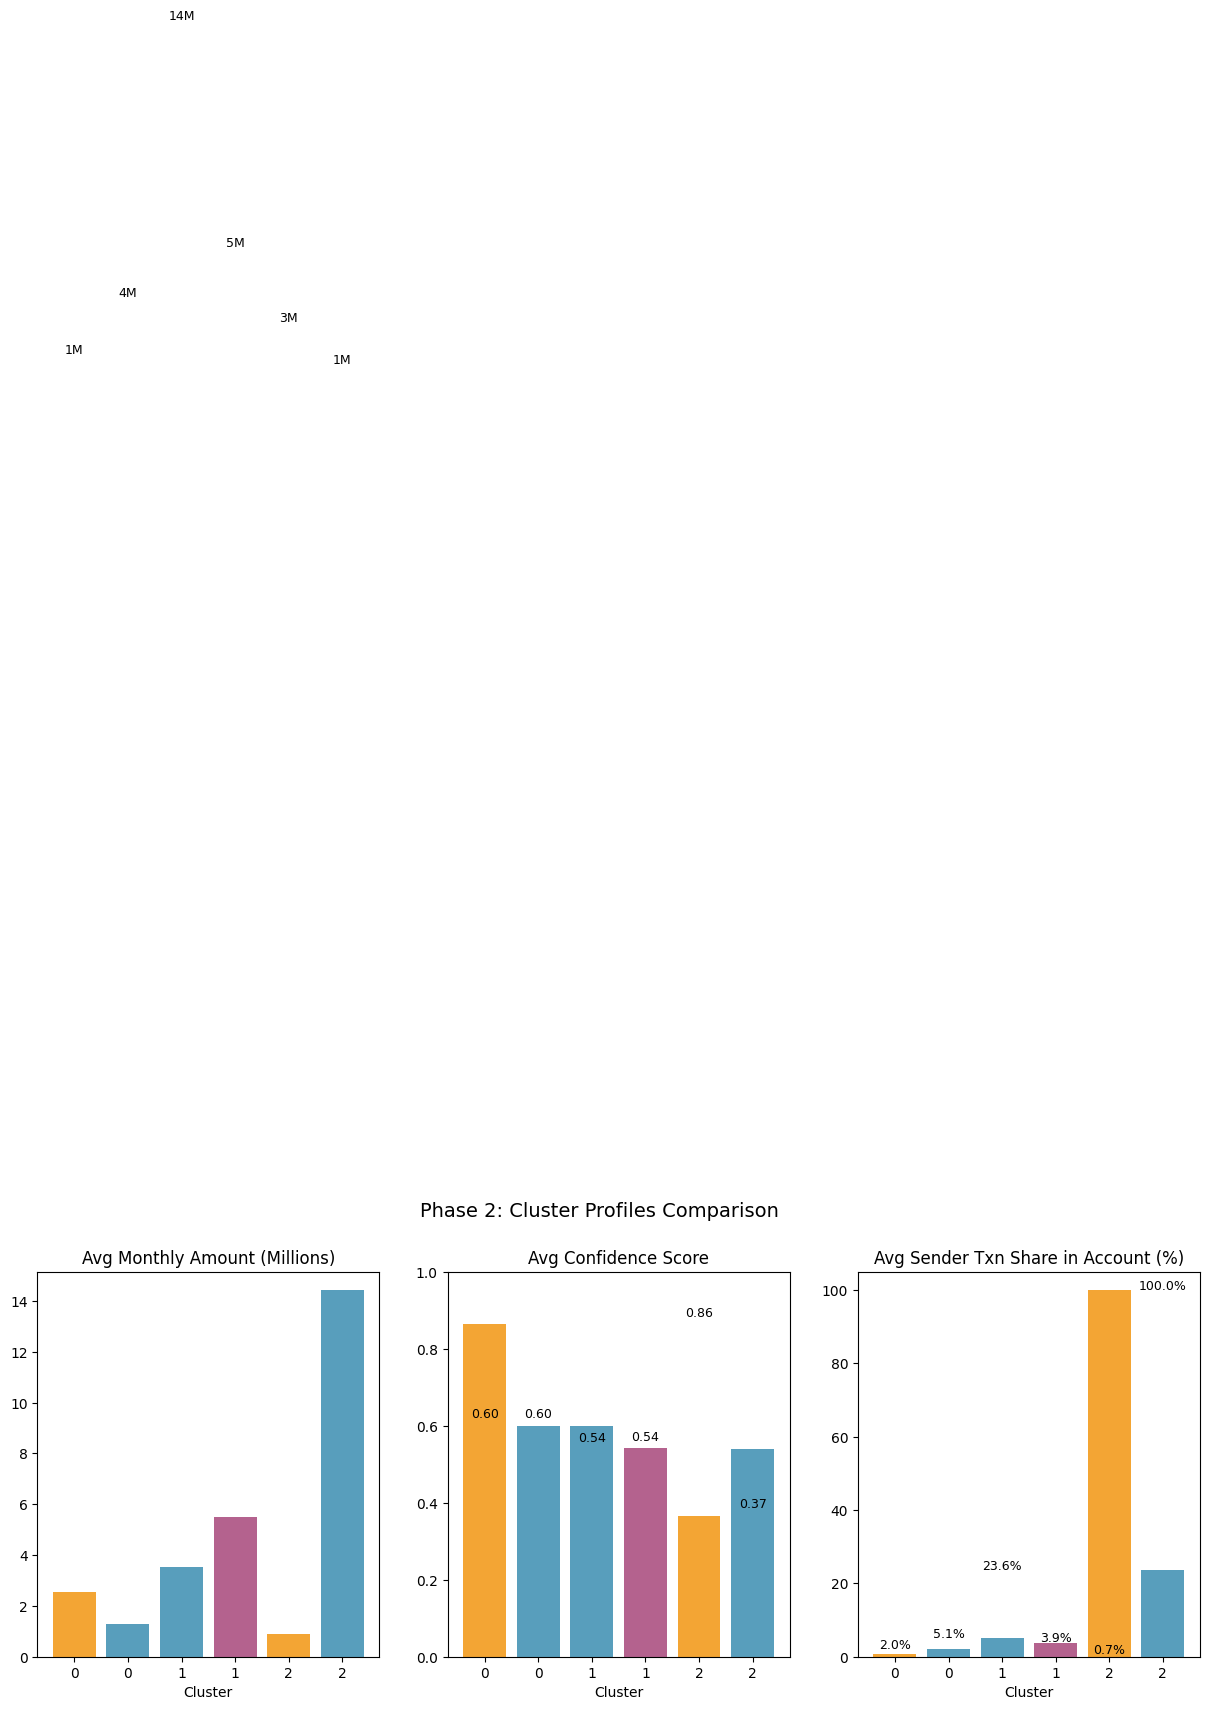

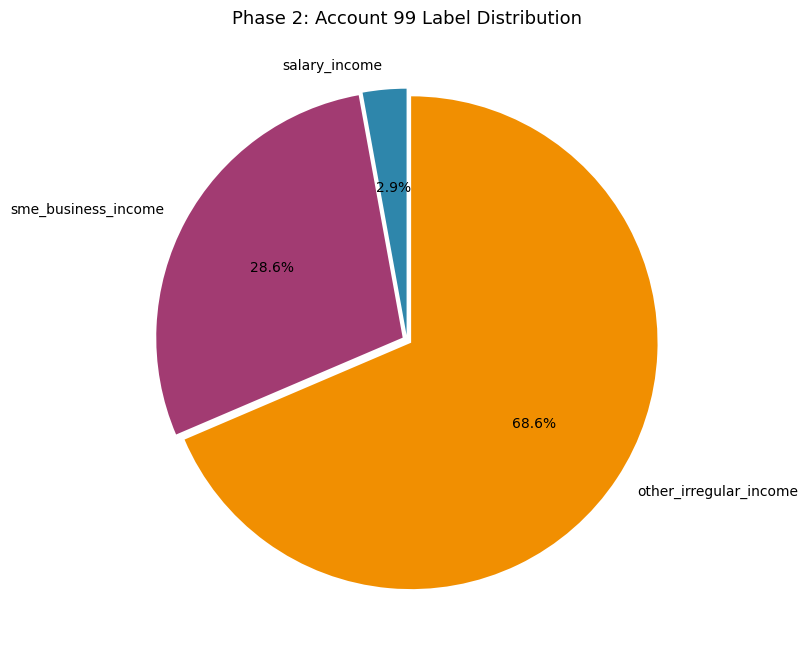

In [6]:
# Phase 2 Visualization 1: Final Label Profiles (cleaned, no duplicated cluster rows)
label_profile = (
    account_label_view.groupby("predicted_income_type", as_index=False)
    .agg(
        senders=("sender", "size"),
        average_monthly_amount=("average_monthly_amount", "mean"),
        confidence_score=("confidence_score", "mean"),
        sender_txn_share_in_account=("sender_txn_share_in_account", "mean"),
    )
)
label_profile["label_order"] = label_profile["predicted_income_type"].map(LABEL_ORDER)
label_profile = label_profile.sort_values("label_order")
label_names = [LABELS.get(x, x) for x in label_profile["predicted_income_type"]]
colors = [COLORS.get(x, "#888888") for x in label_profile["predicted_income_type"]]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bars1 = axes[0].bar(label_names, label_profile["average_monthly_amount"] / 1_000_000, color=colors, edgecolor="black", alpha=0.85)
axes[0].set_title("Avg Monthly Amount (Millions)")
axes[0].tick_params(axis="x", rotation=15)
axes[0].bar_label(bars1, labels=[f"{v:,.2f}M" for v in label_profile["average_monthly_amount"] / 1_000_000], padding=3, fontsize=9)

bars2 = axes[1].bar(label_names, label_profile["confidence_score"], color=colors, edgecolor="black", alpha=0.85)
axes[1].set_title("Avg Confidence Score")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=15)
axes[1].bar_label(bars2, labels=[f"{v:.2f}" for v in label_profile["confidence_score"]], padding=3, fontsize=9)

bars3 = axes[2].bar(label_names, label_profile["sender_txn_share_in_account"] * 100, color=colors, edgecolor="black", alpha=0.85)
axes[2].set_title("Avg Sender Txn Share in Account (%)")
axes[2].tick_params(axis="x", rotation=15)
axes[2].bar_label(bars3, labels=[f"{v:.1f}%" for v in label_profile["sender_txn_share_in_account"] * 100], padding=3, fontsize=9)

fig.suptitle("Phase 2: Final Label Profiles", fontsize=14)
plt.tight_layout()
plt.show()

# Phase 2 Visualization 2: Cluster Label Flow (cluster baseline -> final label)
flow = (
    account_label_view.groupby(["cluster_income_type", "predicted_income_type"], as_index=False)
    .size()
    .pivot(index="cluster_income_type", columns="predicted_income_type", values="size")
    .fillna(0)
)
flow = flow.reindex(index=LABEL_ORDER.keys(), columns=LABEL_ORDER.keys(), fill_value=0)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(flow.values, cmap="Blues")
ax.set_xticks(range(len(flow.columns)))
ax.set_xticklabels([LABELS.get(c, c) for c in flow.columns], rotation=20)
ax.set_yticks(range(len(flow.index)))
ax.set_yticklabels([LABELS.get(c, c) for c in flow.index])
ax.set_xlabel("Final Label")
ax.set_ylabel("Cluster Baseline Label")
ax.set_title(f"Phase 2: Label Flow Matrix — Account {ACCOUNT_ID}")
for i in range(flow.shape[0]):
    for j in range(flow.shape[1]):
        ax.text(j, i, int(flow.values[i, j]), ha="center", va="center", color="black", fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Phase 2 Visualization 3: Account Label Distribution
dist_colors = [COLORS.get(t, "#888") for t in account_distribution["predicted_income_type"]]
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    account_distribution["sender_count"],
    labels=[LABELS.get(x, x) for x in account_distribution["predicted_income_type"]],
    colors=dist_colors,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.03] * len(account_distribution),
)
ax.set_title(f"Phase 2: Account {ACCOUNT_ID} Label Distribution", fontsize=13)
plt.show()

## Phase 3 - Income Estimate (One Account)

This phase answers: after labeling senders, how much estimated income belongs to salary, SME, and other buckets?

It should not repeat the Phase 2 sender label table. It summarizes money by bucket and then shows the month-by-month timeline by label.

In [7]:
income_bucket_map = {
    "salary_income": "salary_income_est",
    "sme_business_income": "sme_income_est",
    "other_irregular_income": "other_income_est",
}

account_income_by_sender = account_model.copy()
account_income_by_sender["income_bucket"] = account_income_by_sender[
    "predicted_income_type"
].map(income_bucket_map)
account_income_by_sender["estimated_total_amount"] = (
    account_income_by_sender["average_monthly_amount"]
    * account_income_by_sender["active_months"]
)

account_summary = (
    account_income_by_sender.groupby("income_bucket", as_index=False)
    .agg(
        sender_count=("sender", "size"),
        estimated_total_amount=("estimated_total_amount", "sum"),
        average_confidence=("confidence_score", "mean"),
    )
)
bucket_order = {
    "salary_income_est": 0,
    "sme_income_est": 1,
    "other_income_est": 2,
}
account_summary["bucket_order"] = account_summary["income_bucket"].map(bucket_order)
account_summary = account_summary.sort_values("bucket_order").drop(columns="bucket_order")

real_income_est = account_summary.loc[
    account_summary["income_bucket"].isin(["salary_income_est", "sme_income_est"]),
    "estimated_total_amount",
].sum()

print(f"Monthly rollup income estimate for account_id={ACCOUNT_ID}")
print(f"real_income_est: {real_income_est:,.0f}")
show_table(account_summary, title=f"Account {ACCOUNT_ID} Income Summary", page_length=10)


Monthly rollup income estimate for account_id=99
real_income_est: 23,687,557

Account 99 Income Summary


,income_bucket,sender_count,estimated_total_amount,average_confidence
1,salary_income_est,1,14519700.0,0.600000
2,sme_income_est,10,9167857.0,0.552857
0,other_income_est,24,5519356.6,0.896801


In [8]:
account_monthly_labeled = account_transactions.merge(
    account_model[["account_id", "sender", "predicted_income_type"]],
    on=["account_id", "sender"],
    how="left",
)

monthly_income_timeline = (
    account_monthly_labeled.groupby(["month", "predicted_income_type"], as_index=False)
    .agg(monthly_amount=("amount", "sum"))
    .pivot_table(
        index="month",
        columns="predicted_income_type",
        values="monthly_amount",
        aggfunc="sum",
        fill_value=0.0,
    )
    .reset_index()
)

for col in ["salary_income", "sme_business_income", "other_irregular_income"]:
    if col not in monthly_income_timeline.columns:
        monthly_income_timeline[col] = 0.0

monthly_income_timeline["real_income"] = (
    monthly_income_timeline["salary_income"]
    + monthly_income_timeline["sme_business_income"]
)
timeline_view = monthly_income_timeline[
    [
        "month",
        "salary_income",
        "sme_business_income",
        "other_irregular_income",
        "real_income",
    ]
].sort_values("month")
show_table(timeline_view, title=f"Account {ACCOUNT_ID} Monthly Income Timeline", page_length=25)



Account 99 Monthly Income Timeline


predicted_income_type,month,salary_income,sme_business_income,other_irregular_income,real_income
0,2025-09,2000000.0,1510207.0,2360000.0,3510207.0
1,2025-10,2000000.0,1369900.0,41356.6,3369900.0
2,2025-11,2000000.0,2324250.0,1335300.0,4324250.0
3,2025-12,2000000.0,1441100.0,1650000.0,3441100.0
4,2026-01,4619700.0,2150400.0,132700.0,6770100.0
5,2026-02,1900000.0,372000.0,0.0,2272000.0


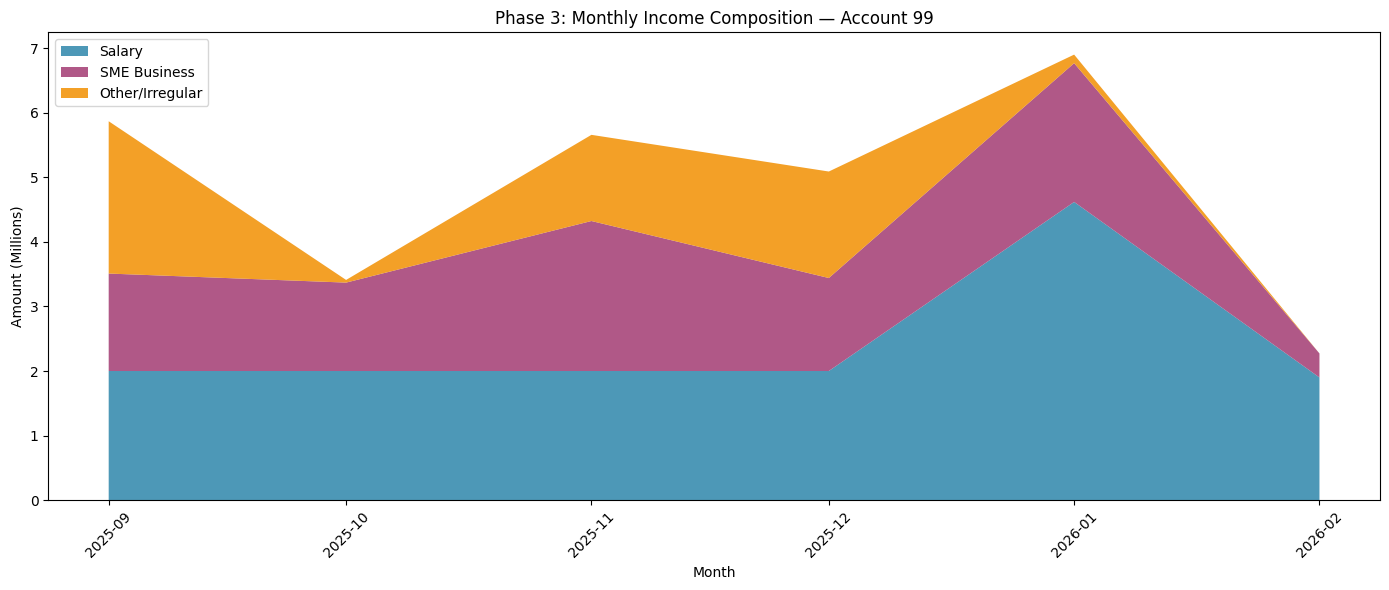

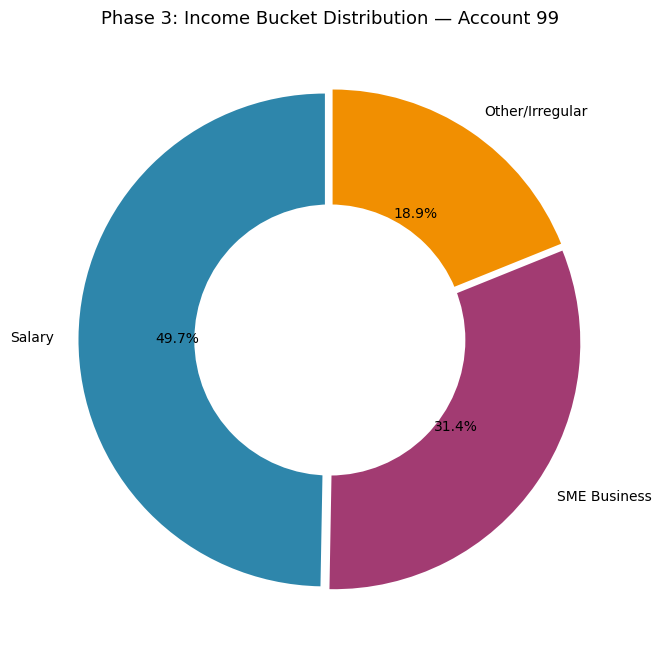

In [9]:
# Phase 3 Visualization 1: Monthly Income Composition
timeline_viz = timeline_view.copy()
timeline_viz["month"] = pd.to_datetime(timeline_viz["month"] + "-01")

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(
    timeline_viz["month"],
    timeline_viz["salary_income"] / 1_000_000,
    timeline_viz["sme_business_income"] / 1_000_000,
    timeline_viz["other_irregular_income"] / 1_000_000,
    labels=["Salary", "SME Business", "Other/Irregular"],
    colors=[COLORS["salary_income"], COLORS["sme_business_income"], COLORS["other_irregular_income"]],
    alpha=0.80,
)
ax.plot(
    timeline_viz["month"],
    timeline_viz["real_income"] / 1_000_000,
    color="black",
    linewidth=2.2,
    marker="o",
    label="Real Income (Salary + SME)",
)
ax.set_xlabel("Month")
ax.set_ylabel("Amount (Millions)")
ax.set_title(f"Phase 3: Monthly Income Composition — Account {ACCOUNT_ID}")
ax.legend(loc="upper left")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# Phase 3 Visualization 2: Income Bucket Donut Chart
summary_viz = account_summary.copy()
bucket_labels = {
    "salary_income_est": "Salary",
    "sme_income_est": "SME Business",
    "other_income_est": "Other/Irregular",
}
summary_viz["bucket_label"] = summary_viz["income_bucket"].map(bucket_labels)
summary_viz["amount_millions"] = summary_viz["estimated_total_amount"] / 1_000_000
summary_viz = summary_viz[summary_viz["amount_millions"] > 0].copy()

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    summary_viz["amount_millions"],
    labels=summary_viz["bucket_label"],
    colors=[COLORS["salary_income"], COLORS["sme_business_income"], COLORS["other_irregular_income"]][: len(summary_viz)],
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.03] * len(summary_viz),
)
centre_circle = plt.Circle((0, 0), 0.55, fc="white")
ax.add_artist(centre_circle)
ax.set_title(f"Phase 3: Income Bucket Distribution — Account {ACCOUNT_ID}", fontsize=13)
plt.show()

## Phase 4 - Scale Monthly Rollup Model to All Accounts
Use the same fitted monthly-rollup KMeans output for all account-sender profiles and summarize estimated income by account.

In [10]:
all_sender_dataset = monthly_model_output.copy()
all_sender_dataset["income_bucket"] = all_sender_dataset["predicted_income_type"].map(
    income_bucket_map
)
all_sender_dataset["estimated_total_amount"] = (
    all_sender_dataset["average_monthly_amount"] * all_sender_dataset["active_months"]
)

account_income_summary_all = (
    all_sender_dataset.groupby(["account_id", "income_bucket"], as_index=False)
    .agg(
        sender_count=("sender", "size"),
        estimated_total_amount=("estimated_total_amount", "sum"),
        average_confidence=("confidence_score", "mean"),
    )
    .pivot_table(
        index="account_id",
        columns="income_bucket",
        values="estimated_total_amount",
        aggfunc="sum",
        fill_value=0.0,
    )
    .reset_index()
)

for col in ["salary_income_est", "sme_income_est", "other_income_est"]:
    if col not in account_income_summary_all.columns:
        account_income_summary_all[col] = 0.0

account_income_summary_all["real_income_est"] = (
    account_income_summary_all["salary_income_est"]
    + account_income_summary_all["sme_income_est"]
)
account_income_summary_all = account_income_summary_all[
    [
        "account_id",
        "salary_income_est",
        "sme_income_est",
        "other_income_est",
        "real_income_est",
    ]
].sort_values("account_id")

monthly_rollup_results = {
    "raw_data": raw_df,
    "monthly_model_output": monthly_model_output,
    "account_model": account_model,
    "cluster_profile": cluster_profile,
    "account_income_summary": account_summary,
    "all_sender_dataset": all_sender_dataset,
    "account_income_summary_all": account_income_summary_all,
}

monthly_rollup_results.keys()


dict_keys(['raw_data', 'monthly_model_output', 'account_model', 'cluster_profile', 'account_income_summary', 'all_sender_dataset', 'account_income_summary_all'])

In [11]:
show_table(account_income_summary_all, title="All Accounts Income Summary", page_length=25)



All Accounts Income Summary


income_bucket,account_id,salary_income_est,sme_income_est,other_income_est,real_income_est
0,1,962622730.0,961094981.0,479340794.0,1.923718e+09
1,2,519605000.0,70000.0,84543000.0,5.196750e+08
2,3,781738650.0,160190096.0,333255308.0,9.419287e+08
3,4,449652000.0,295009600.0,330377522.0,7.446616e+08
4,5,27350000.0,235276666.0,46693000.0,2.626267e+08
5,6,0.0,29000000.0,348210900.0,2.900000e+07
6,7,0.0,71998000.0,109399000.0,7.199800e+07
7,8,5678293.0,2049810.0,60000.0,7.728103e+06
8,9,33450000.0,52850000.0,4887200.0,8.630000e+07
9,10,1898000.0,14116002.0,15175313.0,1.601400e+07


In [12]:
all_sender_view = all_sender_dataset[
    [
        "account_id",
        "sender",
        "cluster_income_type",
        "predicted_income_type",
        "income_label_rule",
        "salary_evidence_score",
        "salary_evidence_flags",
        "confidence_score",
        "total_txns",
        "average_monthly_amount",
        "active_months",
        "average_txns_per_month",
        "sender_txn_share_in_account",
        "monthly_amount_cv",
        "estimated_total_amount",
    ]
].copy()
all_sender_view["label_order"] = all_sender_view["predicted_income_type"].map(LABEL_ORDER)
all_sender_view = all_sender_view.sort_values(
    ["account_id", "label_order", "estimated_total_amount"],
    ascending=[True, True, False],
).drop(columns="label_order")
show_table(all_sender_view, title="All Sender Rows (Monthly Rollup)", page_length=25)



All Sender Rows (Monthly Rollup)


,account_id,sender,cluster_income_type,predicted_income_type,income_label_rule,salary_evidence_score,salary_evidence_flags,confidence_score,total_txns,average_monthly_amount,active_months,average_txns_per_month,sender_txn_share_in_account,monthly_amount_cv,estimated_total_amount
27,1,5020616236,salary_income,salary_income,cluster_model,0.5920,months=1|cv=0|schedule=0|share=1,0.459103,94,8.110389e+07,9,10.444444,0.162912,0.416099,729935000.0
11,1,3655100942,salary_income,salary_income,cluster_model,0.6340,months=1|cv=0|schedule=0|share=1,0.531514,59,1.148428e+07,7,8.428571,0.102253,0.331952,80389987.0
34,1,5031872265,sme_business_income,salary_income,high_recurrence_salary_override,0.7637,months=1|cv=1|schedule=1|share=1,0.600000,9,1.394000e+07,5,1.800000,0.015598,0.051079,69700000.0
12,1,412147358,salary_income,salary_income,cluster_model,0.3172,months=1|cv=0|schedule=0|share=1,0.417820,33,9.040000e+06,4,8.250000,0.057192,0.819558,36160000.0
31,1,5025475051,salary_income,salary_income,cluster_model,0.7374,months=1|cv=1|schedule=0|share=1,0.513177,53,2.399980e+06,10,5.300000,0.091854,0.125186,23999800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1451,99,99103904867.0,other_irregular_income,other_irregular_income,cluster_model,0.4202,months=0|cv=1|schedule=1|share=1,0.911517,1,3.260000e+04,1,1.000000,0.010753,0.000000,32600.0
1426,99,1605114507.0,other_irregular_income,other_irregular_income,cluster_model,0.4202,months=0|cv=1|schedule=1|share=1,0.911479,1,3.000000e+04,1,1.000000,0.010753,0.000000,30000.0
1437,99,3005183226.0,other_irregular_income,other_irregular_income,cluster_model,0.4202,months=0|cv=1|schedule=1|share=1,0.911479,1,3.000000e+04,1,1.000000,0.010753,0.000000,30000.0
1431,99,2015109967.0,other_irregular_income,other_irregular_income,cluster_model,0.4202,months=0|cv=1|schedule=1|share=1,0.911210,1,1.140000e+04,1,1.000000,0.010753,0.000000,11400.0


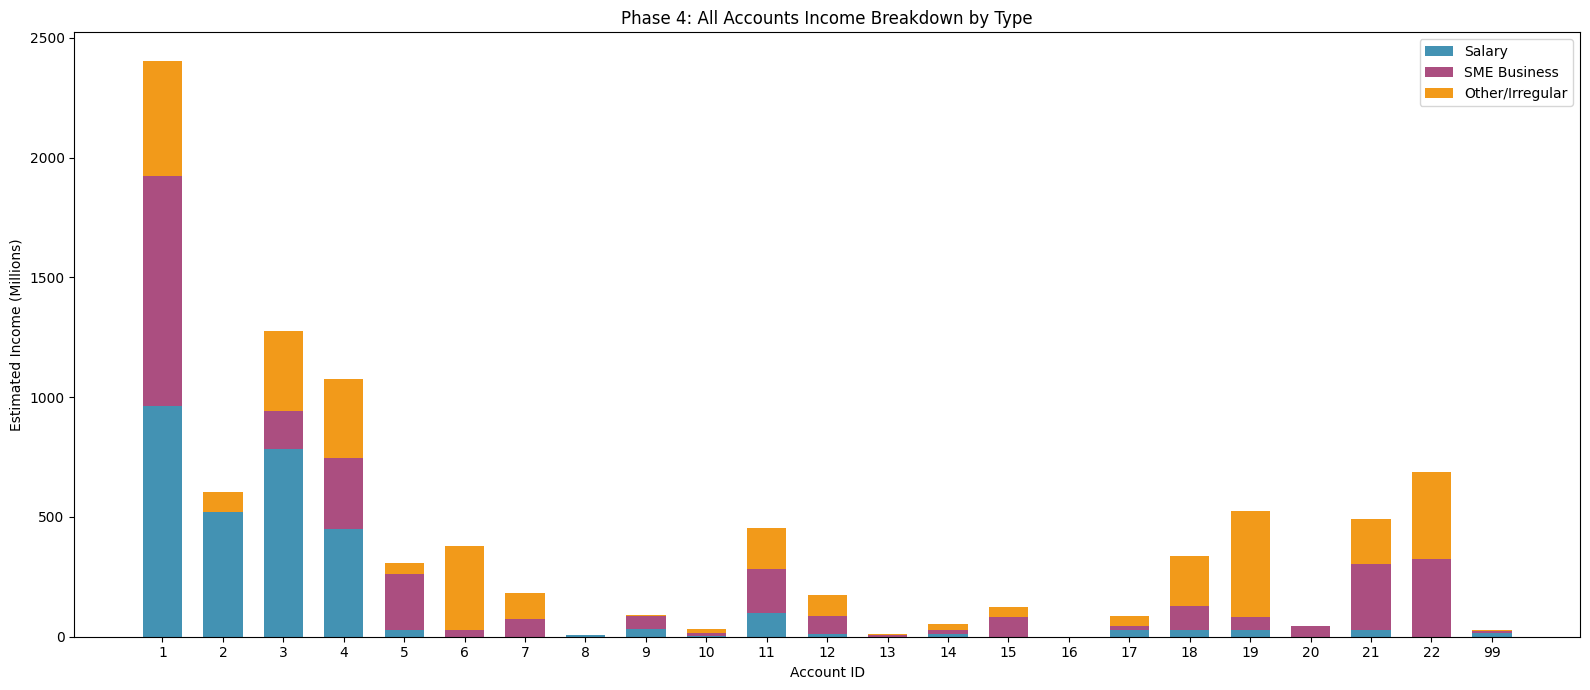

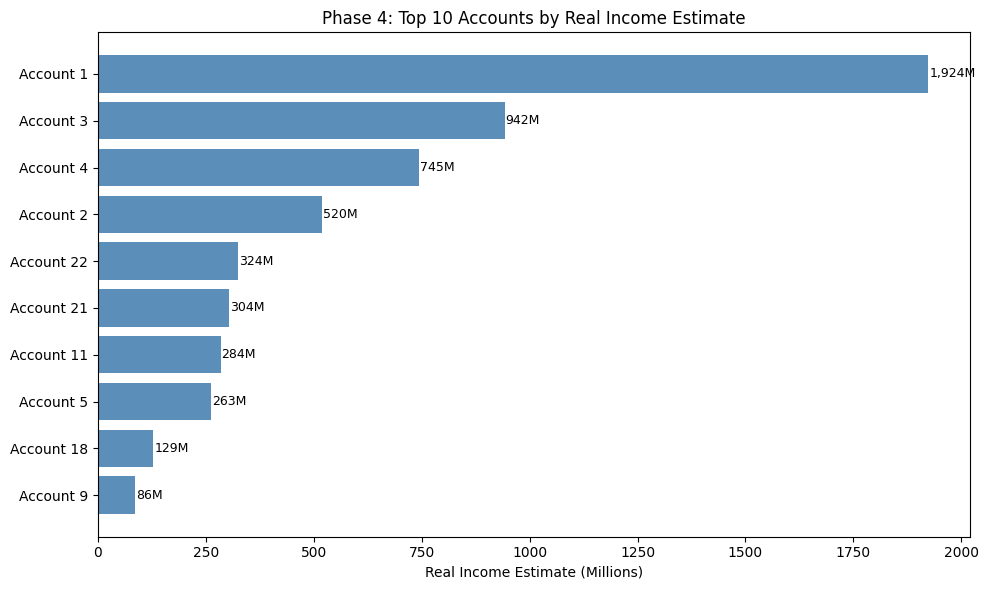

In [13]:
# Phase 4 Visualization 1: All Accounts Income Breakdown (stacked)
accounts_viz = account_income_summary_all.copy().sort_values("account_id")

fig, ax = plt.subplots(figsize=(16, 7))
x = range(len(accounts_viz))
width = 0.68

salary_vals = accounts_viz["salary_income_est"] / 1_000_000
sme_vals = accounts_viz["sme_income_est"] / 1_000_000
other_vals = accounts_viz["other_income_est"] / 1_000_000

ax.bar(x, salary_vals, width, label="Salary", color=COLORS["salary_income"], alpha=0.9, edgecolor="black", linewidth=0.3)
ax.bar(x, sme_vals, width, bottom=salary_vals, label="SME Business", color=COLORS["sme_business_income"], alpha=0.9, edgecolor="black", linewidth=0.3)
ax.bar(x, other_vals, width, bottom=salary_vals + sme_vals, label="Other/Irregular", color=COLORS["other_irregular_income"], alpha=0.9, edgecolor="black", linewidth=0.3)

ax.set_xlabel("Account ID")
ax.set_ylabel("Estimated Income (Millions)")
ax.set_title("Phase 4: All Accounts Income Breakdown by Type")
ax.set_xticks(x)
ax.set_xticklabels(accounts_viz["account_id"], rotation=45, ha="right")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Phase 4 Visualization 2: Top 10 Accounts by Real Income (Horizontal Bar)
top_accounts = accounts_viz.nlargest(10, "real_income_est").copy()
top_accounts["real_income_millions"] = top_accounts["real_income_est"] / 1_000_000

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    [f"Account {a}" for a in top_accounts["account_id"]],
    top_accounts["real_income_millions"],
    color="#5B8FB9",
    edgecolor="black",
    alpha=0.85,
)
ax.set_xlabel("Real Income Estimate (Millions)")
ax.set_title("Phase 4: Top 10 Accounts by Real Income Estimate")
ax.invert_yaxis()
ax.bar_label(bars, labels=[f"{v:,.2f}M" for v in top_accounts["real_income_millions"]], padding=4, fontsize=9)
plt.tight_layout()
plt.show()

## Optional Export

In [ ]:
account_income_summary_all.to_csv("monthly_rollup_account_income_summary_all.csv", index=False)
all_sender_dataset.to_csv("monthly_rollup_sender_dataset.csv", index=False)
print("Saved: monthly_rollup_account_income_summary_all.csv, monthly_rollup_sender_dataset.csv")
